<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
    
Project week 19: Periodic Table and Material Project Database (API)
</div>

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
1- Import lib
</div>

In [461]:
# Import numpy and pandas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

import requests
from bs4 import BeautifulSoup

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
2- Load Periodic Table dataset
</div>

In [462]:
df_periodic = pd.read_excel('../data/RAW_DATA/Periodic Table.xlsx')
df_periodic.head(3)

,Element Symbol,Element Name,Discovery Year,Atomic Number,Atomic Mass (amu),Electron Configuration,Common Isotopes,State at 25°C,Melting Point (°C),Melting Point (°F),...,Radioactivity,Nuclear Stability,Half-Life,Magnetism Type,Magnetic Susceptibility,Emission/Absorption Spectra,Spectral Lines,Biological Role,Environmental Behavior,Allotropes
0,H,Hydrogen,1766,1,1.0080,1s¹,H-1;H-2,Gas,-259.14,-434.452,...,Low (H-3),Stable (H-1;H-2),H-3: 12.32 years,Diamagnetic,-2.23×10⁻⁹ cm³/mol,Lyman/Balmer series,121.6 nm (Lyman-alpha),"Essential (water, organic compounds)",Highly mobile gas; forms water,Diatomic (H₂)
1,He,Helium,1895,2,4.0026,1s²,He-4;He-3,Gas,-272.2,-458,...,Unknown,Stable,Unknown,Diamagnetic,-1.95×10⁻⁹ cm³/mol,Sharp lines in UV/visible,58.4 nm (strong),Unknown,Inert; escapes atmosphere,Monatomic
2,Li,Lithium,1817,3,6.9400,[He] 2s¹,Li-7;Li-6,Solid,180.54,356.972,...,Low (Li-6 trace),Stable,Unknown,Paramagnetic,1.4×10⁻⁵ cm³/mol,Red flame (670.8 nm),670.8 nm (Li I),"Nerve function, batteries",Soluble salts; bioaccumulates,Unknown


In [463]:
df_periodic.columns

Index(['Element Symbol', 'Element Name', 'Discovery Year', 'Atomic Number',
       'Atomic Mass (amu)', 'Electron Configuration', 'Common Isotopes',
       'State at 25°C', 'Melting Point (°C)', 'Melting Point (°F)',
       'Melting Point (K)', 'Boiling Point (°C)', 'Density (g/cm³)',
       'Color/Appearance', 'Conductivity', 'Hardness/Malleability',
       'Reactivity', 'Electronegativity', 'Ionization Energy (e.g., eV)',
       'Valency', 'Oxidation States', 'Atomic Radius (pm)',
       'Electronegativity Value', 'Ionization Energy Value',
       'Metallic Character', 'Radioactivity', 'Nuclear Stability', 'Half-Life',
       'Magnetism Type', 'Magnetic Susceptibility',
       'Emission/Absorption Spectra', 'Spectral Lines', 'Biological Role',
       'Environmental Behavior', 'Allotropes'],
      dtype='object')

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
3- Material Project Database API 
</div>

In [464]:
import os
with open('../../API_Key_MaterialsProject.txt') as f:
    api_key = f.read().strip()   

print("API key loaded successfully.")

API key loaded successfully.


In [465]:
# Check the list of available fields in Material project site using API
from mp_api.client import MPRester
with MPRester(api_key) as mpr:
    list_of_available_fields = mpr.materials.summary.available_fields
print(list_of_available_fields)

['builder_meta', 'nsites', 'elements', 'nelements', 'composition', 'composition_reduced', 'formula_pretty', 'formula_anonymous', 'chemsys', 'volume', 'density', 'density_atomic', 'symmetry', 'material_id', 'deprecated', 'deprecation_reasons', 'last_updated', 'origins', 'warnings', 'structure', 'property_name', 'task_ids', 'uncorrected_energy_per_atom', 'energy_per_atom', 'formation_energy_per_atom', 'energy_above_hull', 'is_stable', 'equilibrium_reaction_energy_per_atom', 'decomposes_to', 'xas', 'grain_boundaries', 'band_gap', 'cbm', 'vbm', 'efermi', 'is_gap_direct', 'is_metal', 'es_source_calc_id', 'bandstructure', 'dos', 'dos_energy_up', 'dos_energy_down', 'is_magnetic', 'ordering', 'total_magnetization', 'total_magnetization_normalized_vol', 'total_magnetization_normalized_formula_units', 'num_magnetic_sites', 'num_unique_magnetic_sites', 'types_of_magnetic_species', 'bulk_modulus', 'shear_modulus', 'universal_anisotropy', 'homogeneous_poisson', 'e_total', 'e_ionic', 'e_electronic',

In [466]:
df_periodic['Element Symbol']

0       H
1      He
2      Li
3      Be
4       B
       ..
113    Fl
114    Mc
115    Lv
116    Ts
117    Og
Name: Element Symbol, Length: 118, dtype: object

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
3-1- Create a dataset (mp_data) with columns Element Symbol, symmetry, and volume from Material Project using API
</div>

In [467]:
# with MPRester(api_key) as mpr:
#     docs = mpr.materials.summary.search(
#         formula=df_periodic['Element Symbol'].tolist(),
#         num_elements=1,
#     )

# docs    

In [468]:
elements = df_periodic['Element Symbol'].tolist()

with MPRester(api_key) as mpr:
    docs = mpr.materials.summary.search(
        formula=elements,
        num_elements=1,
        fields=["formula_pretty", "symmetry", "volume", "energy_above_hull"]
    )

mp_df = pd.DataFrame([{
    "Element Symbol": d.formula_pretty,
    "symmetry": d.symmetry.symbol if d.symmetry else None,
    "volume": d.volume,
    "energy_above_hull": d.energy_above_hull
} for d in docs])

# Select most stable polymorph using apply
mp_data = (
    mp_df.groupby("Element Symbol", sort=False)
         .apply(lambda g: g.loc[g["energy_above_hull"].idxmin(), ["symmetry", "volume"]]
                if not g.empty else pd.Series({"symmetry": None, "volume": None}))
         .reset_index()
         .set_index("Element Symbol")
         .reindex(elements)     # enforce exact same order as df_periodic
         .reset_index()
)

print("New DataFrame shape:", mp_data.shape)
mp_data.head(5)

Retrieving SummaryDoc documents: 100%|██████████| 834/834 [00:00<?, ?it/s]

New DataFrame shape: (118, 3)



C:\Users\ASUS\AppData\Local\Temp\ipykernel_18200\3260967536.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.loc[g["energy_above_hull"].idxmin(), ["symmetry", "volume"]]


,Element Symbol,symmetry,volume
0,H,NaN,NaN
1,He,Im-3m,17.293960
2,Li,R-3m,61.205660
3,Be,P6_3/mmc,31.796370
4,B,R-3m,86.749163


<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
3-2- Create a  new column (Compounds) in the mp_data from Material Project using API
</div>

In [469]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def get_compounds(elem):
    """Fetch unique formula_pretty for compounds containing elem."""
    with MPRester(api_key) as mpr:
        docs = mpr.materials.summary.search(
            elements=[elem],
            fields=["formula_pretty"],
            num_chunks=2,      # up to 200 compounds per element
            chunk_size=100
        )
        formulas = [d.formula_pretty for d in docs if d.formula_pretty]
        return elem, list(set(formulas))

# Run parallel requests 
results = {}
with ThreadPoolExecutor(max_workers=200) as executor:
    futures = {executor.submit(get_compounds, elem): elem for elem in mp_data['Element Symbol']}
    for future in as_completed(futures):
        elem, comps = future.result()
        results[elem] = comps

# Map results back to DataFrame
mp_data['Compounds'] = mp_data['Element Symbol'].map(results)
mp_data.head(5)

Retrieving SummaryDoc documents:   0%|          | 0/200 [00:00<?, ?it/s]





Retrieving SummaryDoc documents: 100%|██████████| 200/200 [00:00<00:00, 431.04it/s]














Retrieving SummaryDoc documents: 100%|██████████| 200/200 [00:00<00:00, 366.37it/s]





Retrieving SummaryDoc documents: 100%|██████████| 200/200 [00:00<00:00, 302.50it/s]








































Retrieving SummaryDoc documents: 100%|██████████| 200/200 [00:01<00:00, 137.81it/s]

Retrieving SummaryDoc documents: 100%|██████████| 200/200 [00:01<00:00, 158.19it/s]














Retrieving SummaryDoc documents:   0%|          | 0/2 [00:00<?, ?it/s]


















































Retrieving SummaryDoc documents: 100%|██████████| 2/2 [00:00<00:00, 11.03it/s]












Retrieving SummaryDoc documents:   0%|          | 0/200 [00:00<?, ?it/s]












Retrieving SummaryDoc documents: 100%|██████████| 200/200 [00:01<00:00, 193.83it/s]













































Re

AttributeError: 'tqdm_asyncio' object has no attribute 'sp'

In [ ]:
# Check the mp_data (created using API)
mp_data.head(4)

,Element Symbol,symmetry,volume,Compounds
0,H,NaN,NaN,"[HW, KH, Pa3H, Na2HF4, NiH, Sr2HCl2, NaHS, HPd..."
1,He,Im-3m,17.29396,"[HeSiO2, He]"
2,Li,R-3m,61.20566,"[LiSi3, LiW3, LiCu3, LiPu3, LiHg, LiAg, LiGe3,..."
3,Be,P6_3/mmc,31.79637,"[K3Be, BeSnP2, ZrBeSi, BeSiP2, BeGe3, Be(B6C)2..."


<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
3-3- Save the mp_data DataFrame of Material Project to CSV 
</div>


In [ ]:
mp_data.to_csv('../data/RAW_DATA/mp_element_properties.csv', index=False)
print("Saved to 'mp_element_properties.csv'")

Saved to 'mp_element_properties.csv'


<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
4-1- Merge the mp_data DataFrame with the original periodic table 
</div>

In [ ]:
# Merge on 'Element Symbol' (left join keeps all original rows)
df_combined = df_periodic.merge(mp_data, on='Element Symbol', how='left')

print("Combined shape:", df_combined.shape)
df_combined[['Element Symbol', 'symmetry', 'volume']].head()

Combined shape: (118, 38)


,Element Symbol,symmetry,volume
0,H,NaN,NaN
1,He,Im-3m,17.293960
2,Li,R-3m,61.205660
3,Be,P6_3/mmc,31.796370
4,B,R-3m,86.749163


In [ ]:
df_combined.head(5)

,Element Symbol,Element Name,Discovery Year,Atomic Number,Atomic Mass (amu),Electron Configuration,Common Isotopes,State at 25°C,Melting Point (°C),Melting Point (°F),...,Magnetism Type,Magnetic Susceptibility,Emission/Absorption Spectra,Spectral Lines,Biological Role,Environmental Behavior,Allotropes,symmetry,volume,Compounds
0,H,Hydrogen,1766,1,1.0080,1s¹,H-1;H-2,Gas,-259.14,-434.452,...,Diamagnetic,-2.23×10⁻⁹ cm³/mol,Lyman/Balmer series,121.6 nm (Lyman-alpha),"Essential (water, organic compounds)",Highly mobile gas; forms water,Diatomic (H₂),NaN,NaN,"[HW, KH, Pa3H, Na2HF4, NiH, Sr2HCl2, NaHS, HPd..."
1,He,Helium,1895,2,4.0026,1s²,He-4;He-3,Gas,-272.2,-458,...,Diamagnetic,-1.95×10⁻⁹ cm³/mol,Sharp lines in UV/visible,58.4 nm (strong),Unknown,Inert; escapes atmosphere,Monatomic,Im-3m,17.293960,"[HeSiO2, He]"
2,Li,Lithium,1817,3,6.9400,[He] 2s¹,Li-7;Li-6,Solid,180.54,356.972,...,Paramagnetic,1.4×10⁻⁵ cm³/mol,Red flame (670.8 nm),670.8 nm (Li I),"Nerve function, batteries",Soluble salts; bioaccumulates,Unknown,R-3m,61.205660,"[LiSi3, LiW3, LiCu3, LiPu3, LiHg, LiAg, LiGe3,..."
3,Be,Beryllium,1798,4,9.0120,[He] 2s²,Be-9,Solid,1287,2348.6,...,Diamagnetic,-1.2×10⁻⁵ cm³/mol,Green flame lines,457.3 nm,Bone structure (trace),Low solubility; toxic dust,Unknown,P6_3/mmc,31.796370,"[K3Be, BeSnP2, ZrBeSi, BeSiP2, BeGe3, Be(B6C)2..."
4,B,Boron,1808,5,10.8100,[He] 2s²2p¹,B-11;B-10,Solid,2076,3768.8,...,Diamagnetic,-8.7×10⁻⁶ cm³/mol,Green flame (546 nm),249.8 nm (strong),Plant nutrient (boric acid),Insoluble; leaches slowly,"Amorphous, α-rhombohedral, β-rhombohedral",R-3m,86.749163,"[BOs, Cr4B, CsB, Re3B, Ga3B, BPd5, BCl2, B, Ta..."


<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
4-2- Save the combined DataFrame to CSV 
</div>

In [470]:
df_combined.to_csv('../data/PROCESSED_DATA/Finall_element_properties.csv', index=False)
print("Saved to 'Finall_element_properties.csv'")
df_combined.head(5)

Saved to 'Finall_element_properties.csv'


,Element Symbol,Element Name,Discovery Year,Atomic Number,Atomic Mass (amu),Electron Configuration,Common Isotopes,State at 25°C,Melting Point (°C),Melting Point (°F),...,Magnetism Type,Magnetic Susceptibility,Emission/Absorption Spectra,Spectral Lines,Biological Role,Environmental Behavior,Allotropes,symmetry,volume,Compounds
0,H,Hydrogen,1766,1,1.0080,1s¹,H-1;H-2,Gas,-259.14,-434.452,...,Diamagnetic,-2.23×10⁻⁹ cm³/mol,Lyman/Balmer series,121.6 nm (Lyman-alpha),"Essential (water, organic compounds)",Highly mobile gas; forms water,Diatomic (H₂),NaN,NaN,"[HW, KH, Pa3H, Na2HF4, NiH, Sr2HCl2, NaHS, HPd..."
1,He,Helium,1895,2,4.0026,1s²,He-4;He-3,Gas,-272.2,-458,...,Diamagnetic,-1.95×10⁻⁹ cm³/mol,Sharp lines in UV/visible,58.4 nm (strong),Unknown,Inert; escapes atmosphere,Monatomic,Im-3m,17.293960,"[HeSiO2, He]"
2,Li,Lithium,1817,3,6.9400,[He] 2s¹,Li-7;Li-6,Solid,180.54,356.972,...,Paramagnetic,1.4×10⁻⁵ cm³/mol,Red flame (670.8 nm),670.8 nm (Li I),"Nerve function, batteries",Soluble salts; bioaccumulates,Unknown,R-3m,61.205660,"[LiSi3, LiW3, LiCu3, LiPu3, LiHg, LiAg, LiGe3,..."
3,Be,Beryllium,1798,4,9.0120,[He] 2s²,Be-9,Solid,1287,2348.6,...,Diamagnetic,-1.2×10⁻⁵ cm³/mol,Green flame lines,457.3 nm,Bone structure (trace),Low solubility; toxic dust,Unknown,P6_3/mmc,31.796370,"[K3Be, BeSnP2, ZrBeSi, BeSiP2, BeGe3, Be(B6C)2..."
4,B,Boron,1808,5,10.8100,[He] 2s²2p¹,B-11;B-10,Solid,2076,3768.8,...,Diamagnetic,-8.7×10⁻⁶ cm³/mol,Green flame (546 nm),249.8 nm (strong),Plant nutrient (boric acid),Insoluble; leaches slowly,"Amorphous, α-rhombohedral, β-rhombohedral",R-3m,86.749163,"[BOs, Cr4B, CsB, Re3B, Ga3B, BPd5, BCl2, B, Ta..."


In [ ]:
df_combined.shape

(118, 38)

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
# 5- Data Cleaning

    1. drop duplicated columns
    2. Convert numeric columns to proper numeric types (handle commas, units)
    3. Handle missing values (impute or flag)
    4. Remove rows with critical missing values (e.g., Atomic Number)
    5. Standardize categorical text (e.g., State at 25°C)
    6. Remove duplicate rows (if any)
    7. Rename columns for consistency

</div>


In [ ]:
# Create a copy to work on
df_clean = df_combined.copy()
# 1 drop duplicate columns

df_clean.drop('Ionization Energy Value', axis=1, inplace=True)  
df_clean.drop('Electronegativity Value', axis=1, inplace=True)
df_clean.columns

Index(['Element Symbol', 'Element Name', 'Discovery Year', 'Atomic Number',
       'Atomic Mass (amu)', 'Electron Configuration', 'Common Isotopes',
       'State at 25°C', 'Melting Point (°C)', 'Melting Point (°F)',
       'Melting Point (K)', 'Boiling Point (°C)', 'Density (g/cm³)',
       'Color/Appearance', 'Conductivity', 'Hardness/Malleability',
       'Reactivity', 'Electronegativity', 'Ionization Energy (e.g., eV)',
       'Valency', 'Oxidation States', 'Atomic Radius (pm)',
       'Metallic Character', 'Radioactivity', 'Nuclear Stability', 'Half-Life',
       'Magnetism Type', 'Magnetic Susceptibility',
       'Emission/Absorption Spectra', 'Spectral Lines', 'Biological Role',
       'Environmental Behavior', 'Allotropes', 'symmetry', 'volume',
       'Compounds'],
      dtype='object')

In [ ]:
# 2. Convert numeric columns
numeric_cols = ['Atomic Number', 'Atomic Mass (amu)', 'Melting Point (°C)', 
                'Boiling Point (°C)', 'Density (g/cm³)', 'Electronegativity',
                'Ionization Energy (e.g., eV)', 'Atomic Radius (pm)', 'volume']
for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [ ]:
# Check missing values
df_clean.isnull().sum()

Element Symbol                   0
Element Name                     0
Discovery Year                   0
Atomic Number                    0
Atomic Mass (amu)                0
Electron Configuration           0
Common Isotopes                  0
State at 25°C                    0
Melting Point (°C)              16
Melting Point (°F)               0
Melting Point (K)                0
Boiling Point (°C)              25
Density (g/cm³)                 28
Color/Appearance                 0
Conductivity                     0
Hardness/Malleability            0
Reactivity                       0
Electronegativity               22
Ionization Energy (e.g., eV)    16
Valency                          0
Oxidation States                 0
Atomic Radius (pm)              25
Metallic Character               0
Radioactivity                    0
Nuclear Stability                0
Half-Life                        0
Magnetism Type                   0
Magnetic Susceptibility          0
Emission/Absorption 

In [ ]:
# 3. Handle missing values in numeric columns by interpolating using atomic order
# Sort by atomic number to ensure correct neighbor order
df_clean = df_clean.sort_values('Atomic Number').reset_index(drop=True)

# Columns to fill 
cols_to_fill = ['Melting Point (°C)', 'Boiling Point (°C)', 'Density (g/cm³)', 
                'Atomic Radius (pm)', 'Electronegativity', 
                'Ionization Energy (e.g., eV)', 'volume']
cols_to_fill = [col for col in cols_to_fill if col in df_clean.columns]

# Linear interpolation (adjacent values) for all columns at once
df_clean[cols_to_fill] = df_clean[cols_to_fill].interpolate(method='linear', limit_direction='both')

# Fill any remaining NaNs at extremes (first or last element)
df_clean[cols_to_fill] = df_clean[cols_to_fill].fillna(method='ffill').fillna(method='bfill')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18200\2712915453.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean[cols_to_fill] = df_clean[cols_to_fill].fillna(method='ffill').fillna(method='bfill')


In [ ]:
# 4. Remove rows where critical identifier is missing
df_clean.dropna(subset=['Element Symbol'], inplace=True)

In [ ]:
# 5. Standardize text columns
# Convert 'State at 25°C' to lower case and strip
if 'State at 25°C' in df_clean.columns:
    df_clean['State at 25°C'] = df_clean['State at 25°C'].astype(str).str.strip().str.lower()

In [ ]:
# 6. Check for duplicates
duplicates = df_clean.duplicated(subset=['Element Symbol']).sum()
print(f"Number of duplicate rows based on Element Symbol: {duplicates}")
df_clean.drop_duplicates(subset=['Element Symbol'], keep='first', inplace=True)

Number of duplicate rows based on Element Symbol: 0


In [ ]:
# 7. Rename columns for easier access 
df_clean.rename(columns={
    'Atomic Mass (amu)': 'Atomic_Mass',
    'Melting Point (°C)': 'Melting_Point',
    'Boiling Point (°C)': 'Boiling_Point',
    'Density (g/cm³)': 'Density',
    'Atomic Radius (pm)': 'Atomic_Radius',
    'Electronegativity Value': 'Electronegativity',
    'Ionization Energy (e.g., eV)': 'Ionization_Energy',
    'State at 25°C': 'State',
    'Metallic Character': 'Metallic_Character'
}, inplace=True)

# Show cleaned data info
df_clean.info()

print("\nMissing values after cleaning:")
df_clean.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Element Symbol               118 non-null    object 
 1   Element Name                 118 non-null    object 
 2   Discovery Year               118 non-null    object 
 3   Atomic Number                118 non-null    int64  
 4   Atomic_Mass                  118 non-null    float64
 5   Electron Configuration       118 non-null    object 
 6   Common Isotopes              118 non-null    object 
 7   State                        118 non-null    object 
 8   Melting_Point                118 non-null    float64
 9   Melting Point (°F)           118 non-null    object 
 10  Melting Point (K)            118 non-null    object 
 11  Boiling_Point                118 non-null    float64
 12  Density                      118 non-null    float64
 13  Color/Appearance    

Element Symbol                  0
Element Name                    0
Discovery Year                  0
Atomic Number                   0
Atomic_Mass                     0
Electron Configuration          0
Common Isotopes                 0
State                           0
Melting_Point                   0
Melting Point (°F)              0
Melting Point (K)               0
Boiling_Point                   0
Density                         0
Color/Appearance                0
Conductivity                    0
Hardness/Malleability           0
Reactivity                      0
Electronegativity               0
Ionization_Energy               0
Valency                         0
Oxidation States                0
Atomic_Radius                   0
Metallic_Character              0
Radioactivity                   0
Nuclear Stability               0
Half-Life                       0
Magnetism Type                  0
Magnetic Susceptibility         0
Emission/Absorption Spectra     0
Spectral Lines

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
# 6- Exploratory Data Analysis 

 6-1- Distributions
</div>

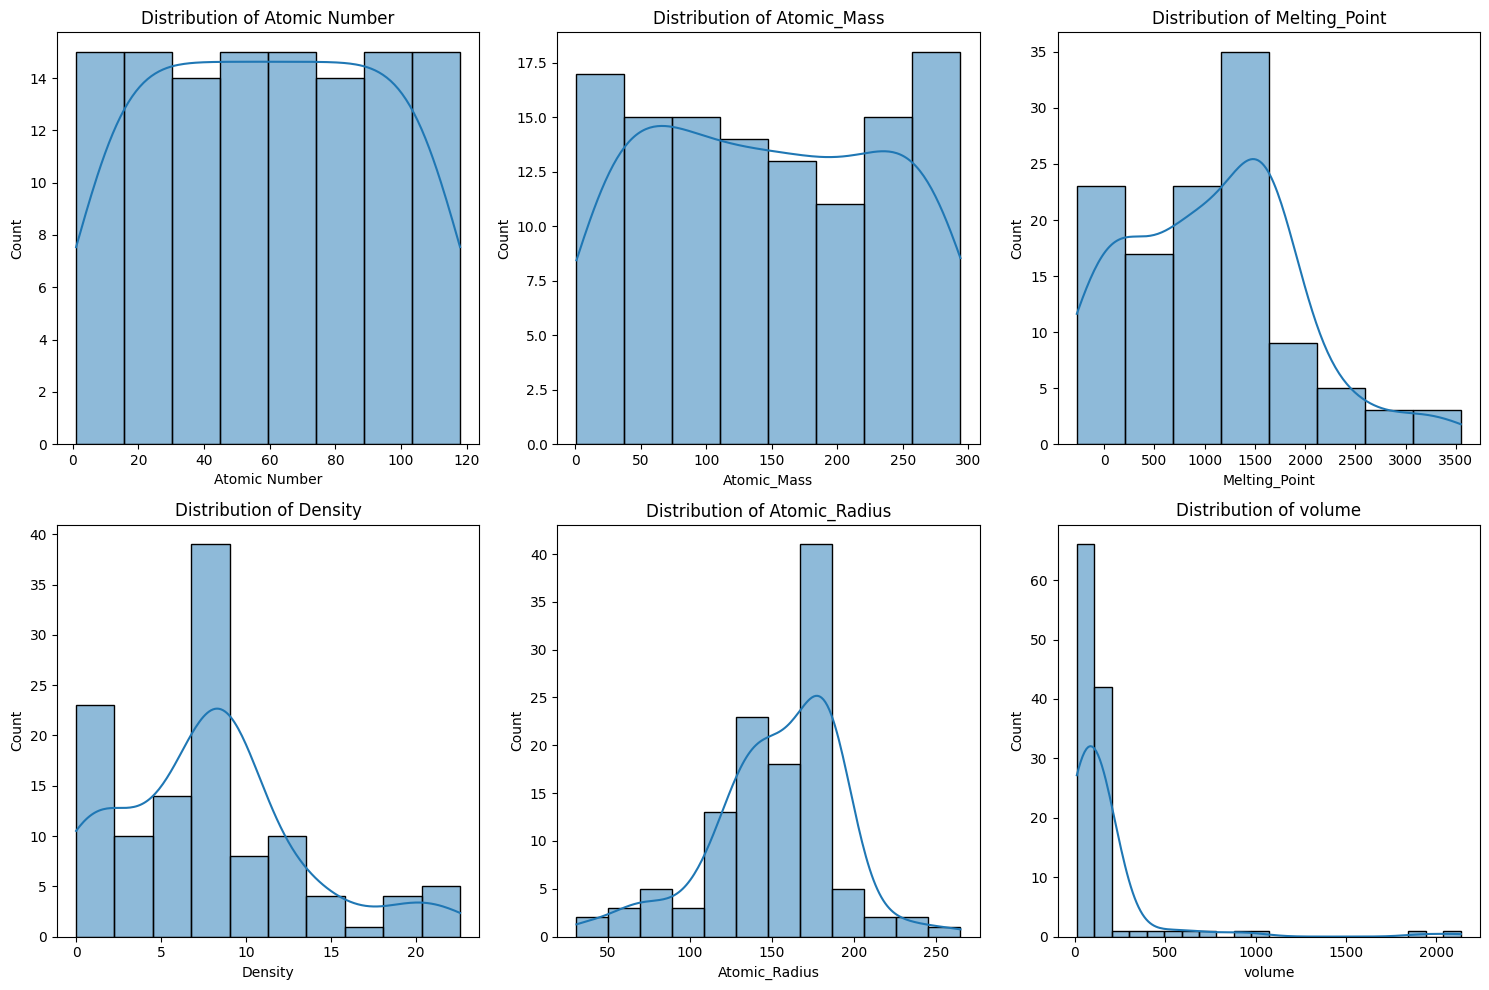

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Columns to plot 
cols = ['Atomic Number', 'Atomic_Mass', 'Melting_Point', 'Density', 'Atomic_Radius', 'volume']
cols = [c for c in cols if c in df_clean.columns]

# Apply plotting using map (functional style)
def plot_column(col_ax):
    col, ax = col_ax
    sns.histplot(df_clean[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')

list(map(plot_column, zip(cols, axes)))

plt.tight_layout()
plt.show()

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
# 6-2- Outlier Checking – without removal
</div>

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18200\1899748793.py:18: UserWarning: When passing multiple axes, layout keyword is ignored.
  df_num.plot(


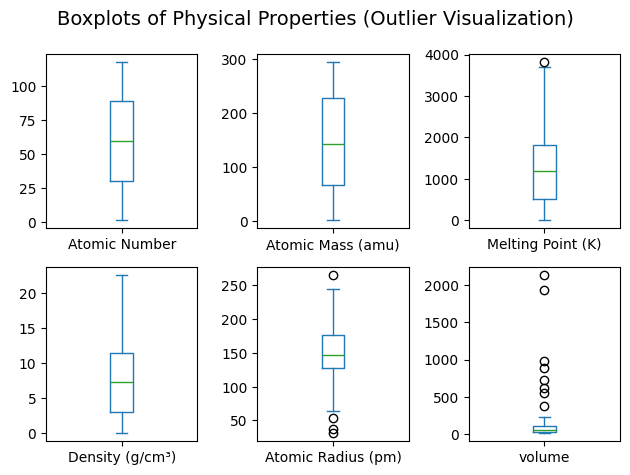

In [ ]:
# Columns of interest 
cols = [
    'Atomic Number',
    'Atomic Mass (amu)',
    'Melting Point (K)',
    'Density (g/cm³)',
    'Atomic Radius (pm)',
    'volume'
]

# Ensure numeric 
df_num = df_combined[cols].apply(pd.to_numeric, errors='coerce')

# Create subplots (2 rows × 3 columns) 
fig, axes = plt.subplots(nrows=2, ncols=3)

# Boxplots 
df_num.plot(
    kind='box',
    subplots=True,
    layout=(2, 3),
    sharex=False,
    sharey=False,
    figsize=(12, 6),
    ax=axes
)

# Styling 
fig.suptitle("Boxplots of Physical Properties (Outlier Visualization)", fontsize=14)
plt.tight_layout()
plt.show()

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
# 6-3 Exploratory Data Analysis – Correlation Matrix
</div>

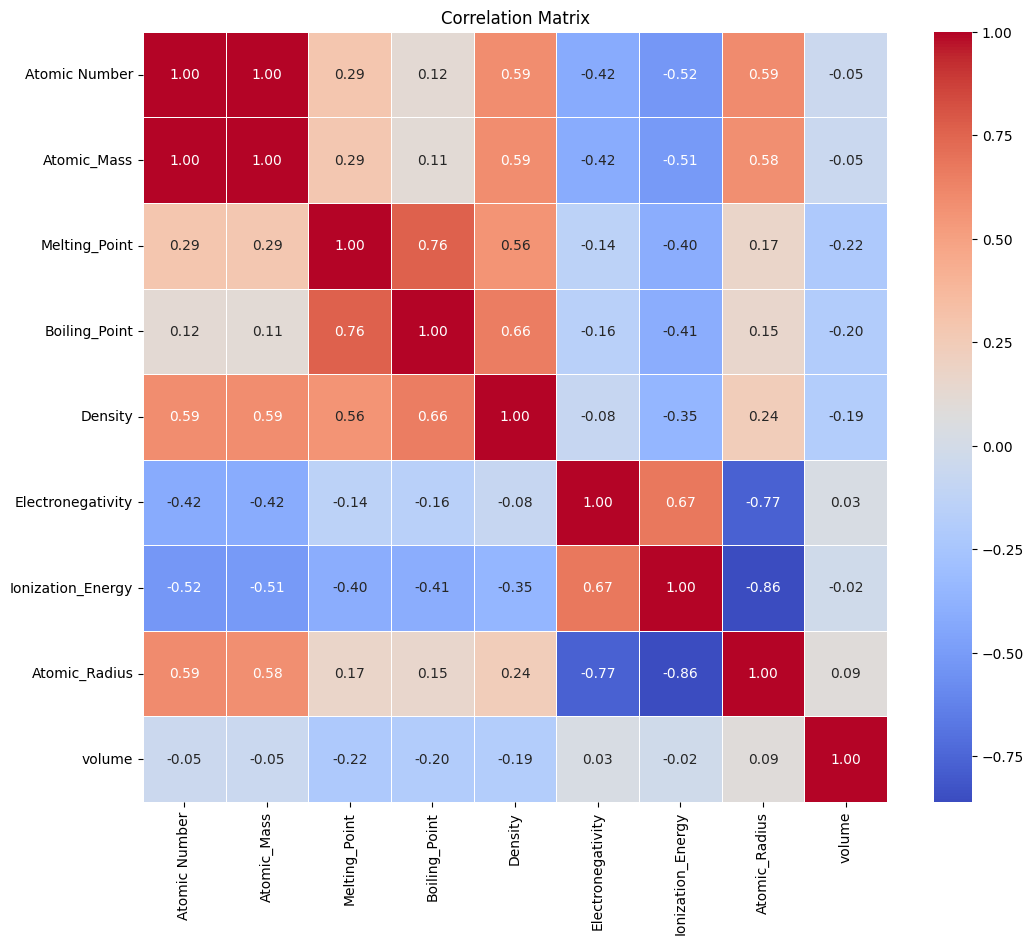

In [ ]:
# Correlation matrix for numeric columns
numeric_df = df_clean.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
# 7- Hypotheses:

Hypothesis 1 – Correlation between Atomic Number and Volume
</div>

In [ ]:
from scipy.stats import pearsonr

# Hypothesis: There is a correlation between atomic number and unit cell volume.
# H0: No correlation (rho = 0)
# H1: Significant correlation (rho != 0)

corr, p_value = pearsonr(df_clean['Atomic Number'], df_clean['volume'])


print(f"Pearson correlation: {corr:.3f}")
print(f"P-value: {p_value:.3e}")

alpha = 0.05
if p_value < alpha:
    print("Reject H0: There is a significant correlation between atomic number and volume.")
else:
    print("Fail to reject H0: No significant correlation found.")

Pearson correlation: -0.054
P-value: 5.640e-01
Fail to reject H0: No significant correlation found.


<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
Showing the Regression Analysis (Predict Volume from Atomic Number) for the Hypothesis 1
</div>

R²: 0.003
Coefficient: -0.459, Intercept: 184.081


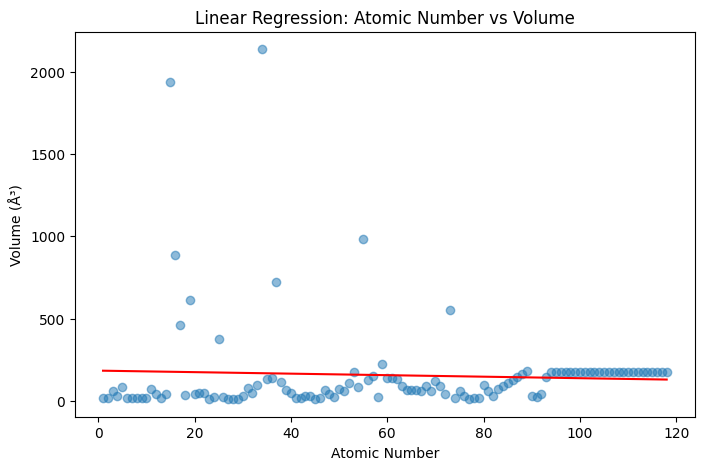

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Prepare data
X = df_clean[['Atomic Number']].dropna()
y = df_clean.loc[X.index, 'volume']

# Linear regression
model = LinearRegression()
model.fit(X, y)

# Predict and evaluate
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print(f"R²: {r2:.3f}")
print(f"Coefficient: {model.coef_[0]:.3f}, Intercept: {model.intercept_:.3f}")

# Plot regression line
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.5)
plt.plot(X, y_pred, color='red')
plt.xlabel('Atomic Number')
plt.ylabel('Volume (Å³)')
plt.title('Linear Regression: Atomic Number vs Volume')
plt.show()

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
Hypothesis 2 – Metallic Character and Magnetism Type (Chi-square)
</div>

In [ ]:
from scipy.stats import chi2_contingency

# Hypothesis: Metallic character and magnetism type are independent.
# H0: They are independent.
# H1: There is an association.

# Create contingency table
contingency = pd.crosstab(df_clean['Metallic_Character'], df_clean['Magnetism Type'])
print("Contingency Table:\n", contingency)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square: {chi2:.3f}, p-value: {p:.3e}")

if p < 0.05:
    print("Reject H0: Metallic character and magnetism type are associated.")
else:
    print("Fail to reject H0: No significant association found.")

Contingency Table:
 Magnetism Type         Antiferromagnetic  Diamagnetic  Ferromagnetic  \
Metallic_Character                                                     
Actinide                               0            0              0   
Alkali metal                           0            0              0   
Alkaline earth                         0            1              0   
Halogen                                0            4              0   
Halogen (predicted)                    0            0              0   
Lanthanide                             0            0              0   
Metalloid                              0            6              0   
Noble gas                              0            6              0   
Noble gas (predicted)                  0            0              0   
Nonmetal                               0            6              0   
Post-transition metal                  0            8              0   
Transition metal                       1    

<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
Hypothesis 3 – Volume difference between Metals and Non-Metals (t-test)
</div>

In [ ]:
from scipy.stats import ttest_ind

# Hypothesis: The mean volume of metals is different from that of non-metals.
# H0: Means are equal.
# H1: Means are not equal.

# 1. Create a binary 'is_metal' column based on Metallic_Character
metal_categories = ['Alkali metal', 'Alkaline earth', 'Transition metal', 
                    'Post-transition metal', 'Lanthanide', 'Actinide']
nonmetal_categories = ['Nonmetal', 'Noble gas', 'Halogen', 'Metalloid', 
                       'Halogen (predicted)', 'Noble gas (predicted)']

# Create the binary column
df_clean['is_metal'] = df_clean['Metallic_Character'].apply(
    lambda x: 'Metal' if x in metal_categories else ('Non-metal' if x in nonmetal_categories else 'Unknown')
)

# 2. Ensure volume is numeric
df_clean['volume'] = pd.to_numeric(df_clean['volume'], errors='coerce')

# 3. Create a subset with relevant columns and drop missing values
df_vol = df_clean[['is_metal', 'volume']].dropna()

# 4. Separate groups
metals = df_vol[df_vol['is_metal'] == 'Metal']['volume']
nonmetals = df_vol[df_vol['is_metal'] == 'Non-metal']['volume']

print(f"Number of metals: {len(metals)}")
print(f"Number of non-metals: {len(nonmetals)}")

# 5. Perform t-test 
if len(metals) > 1 and len(nonmetals) > 1:
    t_stat, p_val = ttest_ind(metals, nonmetals, equal_var=False)  
    print(f"\nt-statistic: {t_stat:.3f}, p-value: {p_val:.3e}")

    if p_val < 0.05:
        print("Reject H0: Significant difference in volume between metals and non-metals.")
    else:
        print("Fail to reject H0: No significant difference in volume.")
else:
    print("Insufficient data for t-test – one group has fewer than 2 observations.")

Number of metals: 91
Number of non-metals: 27

t-statistic: -1.376, p-value: 1.799e-01
Fail to reject H0: No significant difference in volume.


<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
Hypothesis 4 – There is a positive correlation between ionization energy and electronegativity.
</div>

In [ ]:
df_clean['Electronegativity'].values

array([2.2  , 1.59 , 0.98 , 1.57 , 2.04 , 2.55 , 3.04 , 3.44 , 3.98 ,
       2.455, 0.93 , 1.31 , 1.61 , 1.9  , 2.19 , 2.58 , 3.16 , 1.99 ,
       0.82 , 1.   , 1.36 , 1.54 , 1.63 , 1.66 , 1.55 , 1.83 , 1.88 ,
       1.91 , 1.9  , 1.65 , 1.81 , 2.01 , 2.18 , 2.55 , 2.96 , 1.89 ,
       0.82 , 0.95 , 1.22 , 1.33 , 1.6  , 2.16 , 1.9  , 2.2  , 2.28 ,
       2.2  , 1.93 , 1.69 , 1.78 , 1.96 , 2.05 , 2.1  , 2.66 , 1.725,
       0.79 , 0.89 , 1.1  , 1.12 , 1.13 , 1.14 , 1.13 , 1.17 , 1.2  ,
       1.2  , 1.1  , 1.22 , 1.23 , 1.24 , 1.25 , 1.1  , 1.27 , 1.3  ,
       1.5  , 2.36 , 1.9  , 2.2  , 2.2  , 2.28 , 2.54 , 2.   , 1.62 ,
       1.82 , 2.02 , 2.   , 2.2  , 1.45 , 0.7  , 0.9  , 1.1  , 1.3  ,
       1.5  , 1.38 , 1.36 , 1.28 , 1.3  , 1.3  , 1.3  , 1.3  , 1.3  ,
       1.3  , 1.3  , 1.3  , 1.3  , 1.3  , 1.3  , 1.3  , 1.3  , 1.3  ,
       1.3  , 1.3  , 1.3  , 1.3  , 1.3  , 1.3  , 1.3  , 1.3  , 1.3  ,
       1.3  ])

In [ ]:
from scipy.stats import pearsonr
from scipy.stats import ttest_ind

# Hypothesis: There is a positive correlation between ionization energy and electronegativity.
# H0: No correlation (rho = 0)
# H1: Significant positive correlation (rho > 0)

# Drop missing values
# corr_data = df_clean[['Ionization_Energy', 'Electronegativity']].dropna()
corr_data = (
    df_clean[['Ionization_Energy', 'Electronegativity']]
    .apply(pd.to_numeric, errors='coerce')
    )
corr, p_value = pearsonr(corr_data['Ionization_Energy'], corr_data['Electronegativity'])

#t_stat, p_value = ttest_ind(df_clean['Ionization_Energy'], df_clean['Electronegativity'])

print(f"Pearson correlation: {t_stat:.3f}")
print(f"P-value: {p_value:.3e}")

alpha = 0.05
if p_value < alpha:
    print("Reject H0: There is a significant positive correlation between ionization energy and electronegativity.")
else:
    print("Fail to reject H0: No significant positive correlation found.")

Pearson correlation: -1.376
P-value: 5.843e-17
Reject H0: There is a significant positive correlation between ionization energy and electronegativity.


<div class="alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;">
 
10 -Save Cleaned Dataset
</div>

In [460]:
# Save the cleaned dataset for later use
df_clean.to_csv('../data/PROCESSED_DATA/cleaned_periodic_table.csv', index=False)
print("Cleaned dataset saved to '../data/PROCESSED_DATA/cleaned_periodic_table.csv'")

Cleaned dataset saved to '../data/PROCESSED_DATA/cleaned_periodic_table.csv'
